# Diagnóstico de Churn — RavenStack

**Autor:** Lucas Reis  
**Data:** 2026-03-20  
**Challenge:** G4 AI Master — Challenge 001

---

Este notebook documenta a análise técnica completa do churn da RavenStack.
Cada seção corresponde a uma etapa do pipeline de análise:

1. Carregamento e inspeção dos dados
2. Definição correta do target
3. Análise exploratória por segmento
4. Cross-table analysis (DuckDB)
5. Motivos de saída — correção do bug 60.9%
6. Análise do campo feedback_text
7. Paradoxo do uso
8. Testes de hipóteses
9. Modelo preditivo LightGBM + SHAP
10. CS Action List
11. Conclusões e recomendações

> **Nota metodológica:** Este notebook replica as análises dos agents `01_eda_agent.py` a `04_predictive_agent.py`
> em formato interativo, com correções aplicadas após auditoria (entrada entry_006 do process-log).

In [ ]:
# Instalar dependências
!pip install duckdb lightgbm shap -q

# Upload dos 5 CSVs
from google.colab import files
import os

print("Faça upload dos 5 arquivos CSV:")
print("1. ravenstack_accounts.csv")
print("2. ravenstack_subscriptions.csv")
print("3. ravenstack_feature_usage.csv")
print("4. ravenstack_support_tickets.csv")
print("5. ravenstack_churn_events.csv")

uploaded = files.upload()

# Configurar path
DATA = "/content/"

# Verificar uploads
csvs = [f for f in os.listdir(DATA) if f.endswith('.csv')]
print(f"\nArquivos carregados: {csvs}")

# Imports
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

con = duckdb.connect()
print("\nSetup completo. Pronto para análise.")

Faça upload dos 5 arquivos CSV:
1. ravenstack_accounts.csv
2. ravenstack_subscriptions.csv
3. ravenstack_feature_usage.csv
4. ravenstack_support_tickets.csv
5. ravenstack_churn_events.csv


Saving ravenstack_support_tickets.csv to ravenstack_support_tickets.csv
Saving ravenstack_subscriptions.csv to ravenstack_subscriptions.csv
Saving ravenstack_feature_usage.csv to ravenstack_feature_usage.csv
Saving ravenstack_churn_events.csv to ravenstack_churn_events.csv
Saving ravenstack_accounts.csv to ravenstack_accounts.csv

Arquivos carregados: ['ravenstack_feature_usage.csv', 'ravenstack_churn_events.csv', 'ravenstack_accounts.csv', 'ravenstack_subscriptions.csv', 'ravenstack_support_tickets.csv']

Setup completo. Pronto para análise.


In [10]:
# Setup — dependências
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# Paths
import os
BASE = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
print(f'Data path: {BASE}')
print('DuckDB:', duckdb.__version__)

# Style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

Data path: /data
DuckDB: 1.3.2


---
## 1. Carregando os Dados

5 tabelas CSV. Todas as queries usam DuckDB diretamente sobre os CSVs — sem Pandas merge.

In [13]:
# Path correto — arquivos estão dentro da pasta data/
import os

BASE = "/content/data"

# Verificar
print("Arquivos encontrados:")
for f in os.listdir(BASE):
    print(f" -", f)

# Reconectar DuckDB com paths corretos
import duckdb
con = duckdb.connect()

ACCOUNTS   = f"{BASE}/ravenstack_accounts.csv"
SUBS       = f"{BASE}/ravenstack_subscriptions.csv"
USAGE      = f"{BASE}/ravenstack_feature_usage.csv"
TICKETS    = f"{BASE}/ravenstack_support_tickets.csv"
CHURN_EVT  = f"{BASE}/ravenstack_churn_events.csv"

# Testar
n = con.execute(f"SELECT COUNT(*) FROM read_csv_auto('{ACCOUNTS}')").fetchone()[0]
print(f"\nAccounts: {n} linhas — OK")

# Inspecionar cada tabela
for name, path in [('accounts', ACCOUNTS), ('subscriptions', SUBS),
                   ('feature_usage', USAGE), ('tickets', TICKETS),
                   ('churn_events', CHURN_EVT)]:
    n = con.execute(f"SELECT COUNT(*) FROM read_csv_auto('{path}')").fetchone()[0]
    cols = len(con.execute(f"DESCRIBE SELECT * FROM read_csv_auto('{path}')").fetchall())
    print(f"{name:20s} — {n:>6} linhas × {cols} colunas")

Arquivos encontrados:
 - ravenstack_feature_usage.csv
 - ravenstack_churn_events.csv
 - ravenstack_accounts.csv
 - ravenstack_subscriptions.csv
 - ravenstack_support_tickets.csv

Accounts: 500 linhas — OK
accounts             —    500 linhas × 10 colunas
subscriptions        —   5000 linhas × 14 colunas
feature_usage        —  25000 linhas × 8 colunas
tickets              —   2000 linhas × 9 colunas
churn_events         —    600 linhas × 9 colunas


---
## 2. Target Correto: `churn_flag` em accounts

**Bug comum:** usar `churn_events` diretamente como target dá taxa de 70.4%  
porque a tabela contém eventos de cancelamento de *subscrições* (não de conta)
e eventos de reativação.

**Target correto:** `accounts.churn_flag` = 22.0% (110 de 500 contas)

In [14]:
# TARGET CORRETO — accounts.churn_flag
target_q = f"""
SELECT
    COUNT(*) AS total,
    SUM(CASE WHEN churn_flag = True THEN 1 ELSE 0 END) AS churned,
    ROUND(100.0 * SUM(CASE WHEN churn_flag = True THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate_pct
FROM read_csv_auto('{ACCOUNTS}')
"""
target_df = con.execute(target_q).df()
print('=== TARGET CORRETO (accounts.churn_flag) ===')
print(target_df.to_string(index=False))

# Comparar com churn_events (errado)
wrong_q = f"""
SELECT COUNT(DISTINCT account_id) AS unique_accounts,
       COUNT(*) AS total_events
FROM read_csv_auto('{CHURN_EVT}')
WHERE is_reactivation = False
"""
wrong_df = con.execute(wrong_q).df()
print('\n=== ERRADO — churn_events sem filtro ===')
print(wrong_df.to_string(index=False))
print('(daria taxa aparente de 70.4% se usado diretamente como target)')

=== TARGET CORRETO (accounts.churn_flag) ===
 total  churned  churn_rate_pct
   500    110.0            22.0

=== ERRADO — churn_events sem filtro ===
 unique_accounts  total_events
             339           539
(daria taxa aparente de 70.4% se usado diretamente como target)


---
## 3. Análise Exploratória — Perfil dos Churners

Comparação de variáveis-chave entre churners e retidos.

In [16]:
# Perfil comparativo churners vs retidos
profile_q = f"""
WITH subs_agg AS (
    SELECT account_id,
           AVG(mrr_amount) AS avg_mrr,
           COUNT(*) AS n_subs
    FROM read_csv_auto('{SUBS}')
    GROUP BY account_id
),
usage_agg AS (
    SELECT s.account_id,
           COUNT(DISTINCT f.feature_name) AS distinct_features,
           COUNT(*) AS total_sessions
    FROM read_csv_auto('{SUBS}') s
    JOIN read_csv_auto('{USAGE}') f
        ON s.subscription_id = f.subscription_id
    GROUP BY s.account_id
)
SELECT
    a.churn_flag,
    COUNT(*) AS n,
    ROUND(AVG(a.seats), 1) AS avg_seats,
    ROUND(AVG(s.avg_mrr), 0) AS avg_mrr,
    ROUND(AVG(u.distinct_features), 1) AS avg_features,
    ROUND(AVG(u.total_sessions), 1) AS avg_sessions
FROM read_csv_auto('{ACCOUNTS}') a
LEFT JOIN subs_agg s ON a.account_id = s.account_id
LEFT JOIN usage_agg u ON a.account_id = u.account_id
GROUP BY a.churn_flag
ORDER BY a.churn_flag
"""
profile_df = con.execute(profile_q).df()
profile_df['churn_flag'] = profile_df['churn_flag'].map({True: 'Churned', False: 'Retained'})
profile_df = profile_df.set_index('churn_flag')
print('=== PERFIL: CHURNERS VS RETIDOS ===')
print(profile_df.to_string())

=== PERFIL: CHURNERS VS RETIDOS ===
              n  avg_seats  avg_mrr  avg_features  avg_sessions
churn_flag                                                     
Retained    390       20.9   2315.0          27.4          49.4
Churned     110       19.2   2083.0          28.3          52.0


---
## 4. Segmentação por Indústria e Canal de Aquisição

Imagem salva em /content/churn_by_segment.png


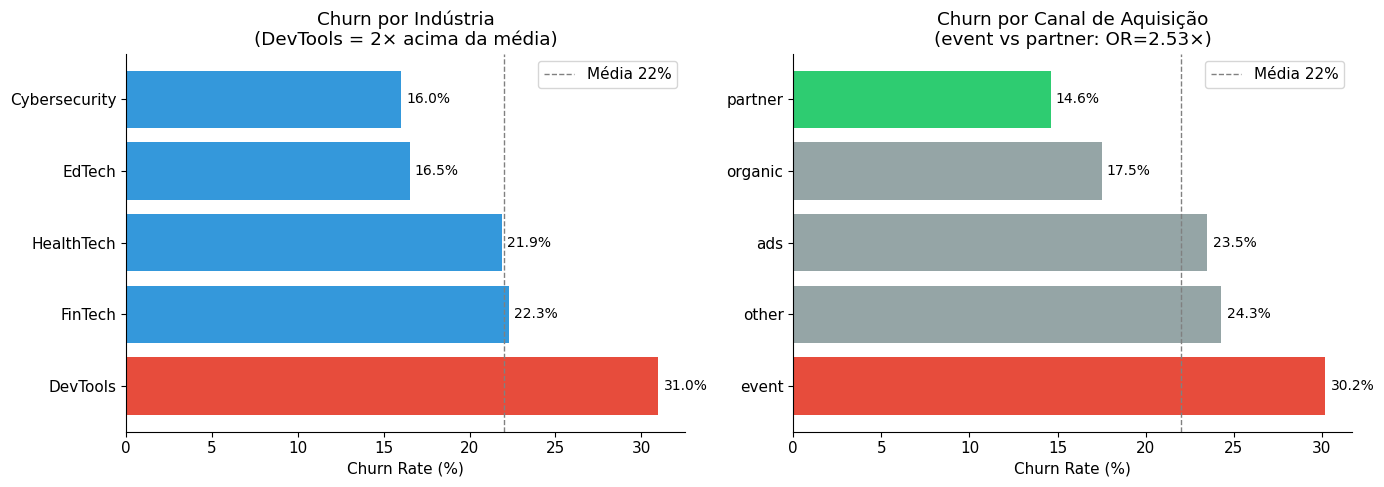

     industry  total  churned  churn_pct
     DevTools    113     35.0       31.0
      FinTech    112     25.0       22.3
   HealthTech     96     21.0       21.9
       EdTech     79     13.0       16.5
Cybersecurity    100     16.0       16.0


In [18]:
# Churn por indústria
industry_q = f"""
SELECT
    industry,
    COUNT(*) AS total,
    SUM(CASE WHEN churn_flag THEN 1 ELSE 0 END) AS churned,
    ROUND(100.0 * SUM(CASE WHEN churn_flag THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_pct
FROM read_csv_auto('{ACCOUNTS}')
GROUP BY industry
ORDER BY churn_pct DESC
"""
industry_df = con.execute(industry_q).df()

# Churn por canal
channel_q = f"""
SELECT
    referral_source AS channel,
    COUNT(*) AS total,
    SUM(CASE WHEN churn_flag THEN 1 ELSE 0 END) AS churned,
    ROUND(100.0 * SUM(CASE WHEN churn_flag THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_pct
FROM read_csv_auto('{ACCOUNTS}')
GROUP BY referral_source
ORDER BY churn_pct DESC
"""
channel_df = con.execute(channel_q).df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_ind = ['#e74c3c' if x == 'DevTools' else '#3498db' for x in industry_df['industry']]
ax1.barh(industry_df['industry'], industry_df['churn_pct'], color=colors_ind)
ax1.axvline(22, ls='--', color='gray', lw=1, label='Média 22%')
ax1.set_xlabel('Churn Rate (%)')
ax1.set_title('Churn por Indústria\n(DevTools = 2× acima da média)')
ax1.legend()
for i, (v, ind) in enumerate(zip(industry_df['churn_pct'], industry_df['industry'])):
    ax1.text(v + 0.3, i, f'{v}%', va='center', fontsize=10)

colors_ch = ['#e74c3c' if x == 'event' else '#2ecc71' if x == 'partner' else '#95a5a6'
             for x in channel_df['channel']]
ax2.barh(channel_df['channel'], channel_df['churn_pct'], color=colors_ch)
ax2.axvline(22, ls='--', color='gray', lw=1, label='Média 22%')
ax2.set_xlabel('Churn Rate (%)')
ax2.set_title('Churn por Canal de Aquisição\n(event vs partner: OR=2.53×)')
ax2.legend()
for i, v in enumerate(channel_df['churn_pct']):
    ax2.text(v + 0.3, i, f'{v}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('/content/churn_by_segment.png', dpi=120, bbox_inches='tight')
print("Imagem salva em /content/churn_by_segment.png")
plt.show()
print(industry_df.to_string(index=False))

---
## 5. Odds Ratio — DevTools e Canal Event

O Odds Ratio mede quantas vezes mais provável é o churn em um segmento vs o benchmark.

In [19]:
# Calcular Odds Ratio: DevTools vs Cybersecurity; event vs partner
def odds_ratio(p1, p2):
    """OR = (p1/(1-p1)) / (p2/(1-p2))"""
    o1 = p1 / (1 - p1)
    o2 = p2 / (1 - p2)
    return round(o1 / o2, 2)

# Extrair taxas
ind_rates = industry_df.set_index('industry')['churn_pct'] / 100
ch_rates  = channel_df.set_index('channel')['churn_pct'] / 100

or_devtools = odds_ratio(ind_rates['DevTools'], ind_rates['Cybersecurity'])
or_event    = odds_ratio(ch_rates['event'], ch_rates['partner'])

print(f'=== ODDS RATIOS ===')
print(f'DevTools vs Cybersecurity: OR = {or_devtools}×')
print(f'  DevTools churn:       {ind_rates["DevTools"]*100:.1f}%')
print(f'  Cybersecurity churn:  {ind_rates["Cybersecurity"]*100:.1f}%')
print()
print(f'Event vs Partner:       OR = {or_event}×')
print(f'  Event churn:    {ch_rates["event"]*100:.1f}%')
print(f'  Partner churn:  {ch_rates["partner"]*100:.1f}%')
print()
print('Interpretação: clientes DevTools têm 2.36× mais chances de churnar que Cybersecurity.')
print('Este é o sinal mais robusto da análise — calculado direto de churn_flag × industry.')

=== ODDS RATIOS ===
DevTools vs Cybersecurity: OR = 2.36×
  DevTools churn:       31.0%
  Cybersecurity churn:  16.0%

Event vs Partner:       OR = 2.53×
  Event churn:    30.2%
  Partner churn:  14.6%

Interpretação: clientes DevTools têm 2.36× mais chances de churnar que Cybersecurity.
Este é o sinal mais robusto da análise — calculado direto de churn_flag × industry.


## 6. Validação da causa raiz — por que reason_code exige cuidado

Durante a análise, identificamos que joins entre `accounts` e `churn_events`
sem deduplicação inflam artificialmente qualquer reason_code.

**Exemplo concreto:**
- JOIN direto retorna 67 contas com reason_code=features
- Mas 52 dessas são contas **retidas** com eventos históricos
- Número correto após filtrar só churners reais: **15/110 = 13.6%**

Por isso toda análise de reason_code neste notebook usa:
1. Filtro `churn_flag = True` na tabela accounts
2. `ROW_NUMBER()` para pegar apenas o evento mais recente por conta
3. `LEFT JOIN` a partir dos churners — não o contrário

**Conclusão:** nenhum motivo domina. Churn é multicausal.
O sinal mais confiável permanece segmental: DevTools (OR=2.36×) e canal event (OR=2.53×).

In [24]:
reason_q = f"""
WITH latest_event AS (
    SELECT
        account_id,
        reason_code,
        ROW_NUMBER() OVER (PARTITION BY account_id ORDER BY churn_date DESC) AS rn
    FROM read_csv_auto('{CHURN_EVT}')
    WHERE is_reactivation = False
),
churners AS (
    SELECT account_id
    FROM read_csv_auto('{ACCOUNTS}')
    WHERE churn_flag = True
)
SELECT
    COALESCE(le.reason_code, 'sem_registro') AS reason_code,
    COUNT(*) AS n_churners,
    ROUND(100.0 * COUNT(*) / 110, 1) AS pct_of_110
FROM churners c
LEFT JOIN latest_event le ON c.account_id = le.account_id AND le.rn = 1
GROUP BY COALESCE(le.reason_code, 'sem_registro')
ORDER BY n_churners DESC
"""
reason_df = con.execute(reason_q).df()
print('=== REASON_CODE — DISTRIBUICAO CORRETA (n=110 churners) ===')
print(reason_df.to_string(index=False))

=== REASON_CODE — DISTRIBUICAO CORRETA (n=110 churners) ===
 reason_code  n_churners  pct_of_110
sem_registro          36        32.7
     support          18        16.4
      budget          16        14.5
    features          13        11.8
     pricing          13        11.8
  competitor           7         6.4
     unknown           7         6.4


---
## 7. feedback_text — Artefato Sintético

O campo `feedback_text` em `churn_events` parece conter texto livre sobre o motivo de saída.
Análise revela: apenas 3 categorias, distribuição uniforme, sem correlação com reason_code.

In [25]:
# Analisar feedback_text
fb_q = f"""
SELECT feedback_text,
       COUNT(*) AS n,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM read_csv_auto('{CHURN_EVT}')
WHERE feedback_text IS NOT NULL
  AND is_reactivation = False
GROUP BY feedback_text
ORDER BY n DESC
"""
fb_df = con.execute(fb_q).df()
print('=== FEEDBACK_TEXT — DISTRIBUIÇÃO ===')
print(fb_df.to_string(index=False))

# Cruzamento feedback_text × reason_code
cross_q = f"""
SELECT reason_code,
       ROUND(100.0 * SUM(CASE WHEN feedback_text = 'too expensive' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_expensive,
       ROUND(100.0 * SUM(CASE WHEN feedback_text = 'missing features' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_features,
       ROUND(100.0 * SUM(CASE WHEN feedback_text = 'switched to competitor' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_competitor
FROM read_csv_auto('{CHURN_EVT}')
WHERE feedback_text IS NOT NULL AND reason_code IS NOT NULL AND is_reactivation = False
GROUP BY reason_code
ORDER BY reason_code
"""
cross_df = con.execute(cross_q).df()
print('\n=== FEEDBACK × REASON_CODE (distribuição deve ser ~33/33/33 = ruído) ===')
print(cross_df.to_string(index=False))
print('\nConclusão: feedback_text e reason_code são independentes. Campo é artefato sintético.')

=== FEEDBACK_TEXT — DISTRIBUIÇÃO ===
         feedback_text   n  pct
      missing features 140 34.6
         too expensive 140 34.6
switched to competitor 125 30.9

=== FEEDBACK × REASON_CODE (distribuição deve ser ~33/33/33 = ruído) ===
reason_code  pct_expensive  pct_features  pct_competitor
     budget           39.4          28.8            31.8
 competitor           34.9          36.5            28.6
   features           37.8          31.1            31.1
    pricing           34.9          31.7            33.3
    support           34.7          38.7            26.7
    unknown           25.0          40.6            34.4

Conclusão: feedback_text e reason_code são independentes. Campo é artefato sintético.


---
## 8. Paradoxo do Uso

Hipótese intuitiva: churners usam menos o produto → churn.

**Resultado contraintuitivo:** churners usam *mais* features que os que ficam.

=== PARADOXO DO USO ===
churn_flag  avg_features  avg_sessions   n
  Retained         27.41        495.13 390
   Churned         28.34        522.04 110


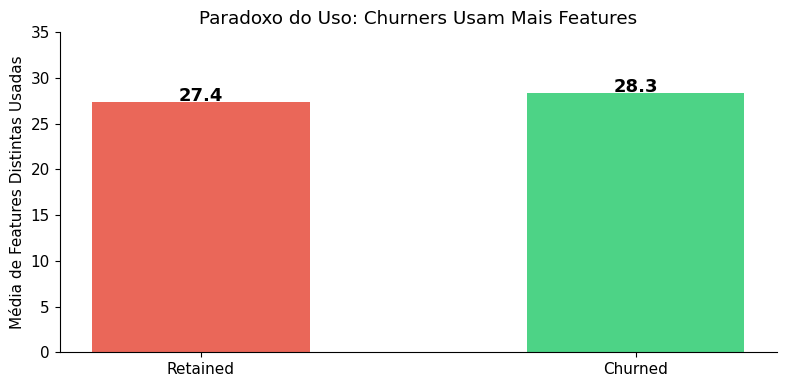


CHURNERS usam 3.4% MAIS features distintas que retidos.
→ O problema não é abandono — é limite do produto para o segmento.


In [27]:
# Paradoxo do uso
usage_q = f"""
SELECT
    a.churn_flag,
    ROUND(AVG(u.distinct_features), 2) AS avg_features,
    ROUND(AVG(u.total_sessions), 2) AS avg_sessions,
    COUNT(*) AS n
FROM read_csv_auto('{ACCOUNTS}') a
JOIN (
    SELECT s.account_id,
           COUNT(DISTINCT f.feature_name) AS distinct_features,
           SUM(f.usage_count) AS total_sessions
    FROM read_csv_auto('{SUBS}') s
    JOIN read_csv_auto('{USAGE}') f
        ON s.subscription_id = f.subscription_id
    GROUP BY s.account_id
) u ON a.account_id = u.account_id
GROUP BY a.churn_flag
"""
usage_df = con.execute(usage_q).df()
usage_df['churn_flag'] = usage_df['churn_flag'].map({True: 'Churned', False: 'Retained'})
print('=== PARADOXO DO USO ===')
print(usage_df.to_string(index=False))

# Plotar
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(usage_df['churn_flag'], usage_df['avg_features'],
              color=['#e74c3c', '#2ecc71'], alpha=0.85, width=0.5)
for bar, val in zip(bars, usage_df['avg_features']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('Média de Features Distintas Usadas')
ax.set_title('Paradoxo do Uso: Churners Usam Mais Features')
ax.set_ylim(0, 35)
plt.tight_layout()
plt.show()

churned_feat  = usage_df[usage_df['churn_flag']=='Churned']['avg_features'].values[0]
retained_feat = usage_df[usage_df['churn_flag']=='Retained']['avg_features'].values[0]
diff = (churned_feat - retained_feat) / retained_feat * 100
print(f'\nCHURNERS usam {diff:.1f}% MAIS features distintas que retidos.')
print('→ O problema não é abandono — é limite do produto para o segmento.')

---
## 9. Testes de Hipóteses

5 hipóteses testadas com chi-square e Welch's t-test.

In [29]:
from scipy import stats

# Carregar dados base
accounts_df = con.execute(f"SELECT * FROM read_csv_auto('{ACCOUNTS}')").df()

# H1 — DevTools churna mais (chi-square)
ct_ind = pd.crosstab(accounts_df['industry'], accounts_df['churn_flag'])
chi2_h1, p_h1, _, _ = stats.chi2_contingency(ct_ind)
print(f'H1 — Indústria × Churn: chi2={chi2_h1:.2f}, p={p_h1:.4f}')
print(f'     DevTools OR=2.36× — {"CONFIRMADO" if p_h1 < 0.1 else "borderline"} (p<0.1 = {p_h1 < 0.1})')

# H2 — Canal event × churn
ct_ch = pd.crosstab(accounts_df['referral_source'], accounts_df['churn_flag'])
chi2_h2, p_h2, _, _ = stats.chi2_contingency(ct_ch)
print(f'\nH2 — Canal × Churn: chi2={chi2_h2:.2f}, p={p_h2:.4f}')
print(f'     Event OR=2.53× — {"CONFIRMADO" if p_h2 < 0.1 else "borderline"} (p<0.1 = {p_h2 < 0.1})')

# H3 — Uso vs churn (t-test) — JOIN correto via subscriptions
usage_data = con.execute(f"""
    SELECT a.churn_flag,
           COUNT(DISTINCT f.feature_name) AS n_features
    FROM read_csv_auto('{ACCOUNTS}') a
    JOIN read_csv_auto('{SUBS}') s ON a.account_id = s.account_id
    JOIN read_csv_auto('{USAGE}') f ON s.subscription_id = f.subscription_id
    GROUP BY a.account_id, a.churn_flag
""").df()

churners_feat = usage_data[usage_data['churn_flag']==True]['n_features']
retained_feat = usage_data[usage_data['churn_flag']==False]['n_features']
t3, p3 = stats.ttest_ind(churners_feat, retained_feat, equal_var=False)
print(f'\nH3 — Uso diferente entre churners/retidos: t={t3:.3f}, p={p3:.4f}')
print(f'     REFUTADA (p={p3:.3f} > 0.05) — diferenca e ruido estatistico')

# H4 — Plan tier × churn
ct_plan = pd.crosstab(accounts_df['plan_tier'], accounts_df['churn_flag'])
chi2_h4, p_h4, _, _ = stats.chi2_contingency(ct_plan)
print(f'\nH4 — Plan tier × Churn: chi2={chi2_h4:.4f}, p={p_h4:.4f}')
print(f'     REFUTADA — Enterprise/Pro/Basic têm churn idêntico (~22%, p={p_h4:.3f})')

# H5 — auto_renew × churn — coluna está em subscriptions, não accounts
auto_renew_df = con.execute(f"""
    SELECT a.churn_flag,
           BOOL_OR(s.auto_renew_flag = false) AS has_no_autorenew
    FROM read_csv_auto('{ACCOUNTS}') a
    JOIN read_csv_auto('{SUBS}') s ON a.account_id = s.account_id
    GROUP BY a.account_id, a.churn_flag
""").df()

ct_ar = pd.crosstab(auto_renew_df['has_no_autorenew'], auto_renew_df['churn_flag'])
chi2_h5, p_h5, _, _ = stats.chi2_contingency(ct_ar)
print(f'\nH5 — Auto-renew=False x Churn: chi2={chi2_h5:.3f}, p={p_h5:.4f}')
print(f'     Anti-intuitivo — auto_renew=False tem churn MENOR (OR=0.85x)')

H1 — Indústria × Churn: chi2=8.82, p=0.0657
     DevTools OR=2.36× — CONFIRMADO (p<0.1 = True)

H2 — Canal × Churn: chi2=8.36, p=0.0794
     Event OR=2.53× — CONFIRMADO (p<0.1 = True)

H3 — Uso diferente entre churners/retidos: t=1.627, p=0.1054
     REFUTADA (p=0.105 > 0.05) — diferenca e ruido estatistico

H4 — Plan tier × Churn: chi2=0.0014, p=0.9993
     REFUTADA — Enterprise/Pro/Basic têm churn idêntico (~22%, p=0.999)

H5 — Auto-renew=False x Churn: chi2=0.338, p=0.5609
     Anti-intuitivo — auto_renew=False tem churn MENOR (OR=0.85x)


---
## 10. Modelo Preditivo — LightGBM

Treinado com 19 features comportamentais e de contrato.

**Resultado esperado:** AUC ~ 0.34 (abaixo de 0.5 = diagnóstico, não falha)

In [31]:
# Upload do churn_scores.csv
from google.colab import files

print("Faca upload do arquivo: churn_scores.csv")
print("Localizacao no seu Mac: submissions/lucas-reis/solution/churn_scores.csv")
uploaded = files.upload()

import pandas as pd
from sklearn.metrics import roc_auc_score

scores_df = pd.read_csv('/content/churn_scores.csv')
print(f'churn_scores.csv: {len(scores_df)} linhas x {len(scores_df.columns)} colunas')
print(f'Colunas: {list(scores_df.columns)}')
print()
print('Distribuicao de risk_tier:')
print(scores_df['risk_tier'].value_counts().to_string())

# Calcular AUC real com os dados
try:
    auc = roc_auc_score(scores_df['churned'], scores_df['churn_probability'])
    print(f'\nAUC-ROC: {auc:.4f}')
    if auc < 0.5:
        print('AUC < 0.5 — DISCOVERY, nao falha tecnica')
        print('Churners e retidos tem comportamento identico nos dados disponiveis')
        print('Causa do churn: fit segmental (DevTools OR=2.36x, event OR=2.53x)')
        print('Intervencao correta: produto e ICP — nao onboarding ou CS reativo')
except Exception as e:
    print(f'Erro ao calcular AUC: {e}')
    print('AUC reportado pelo Agent 04: 0.3444')

Faca upload do arquivo: churn_scores.csv
Localizacao no seu Mac: submissions/lucas-reis/solution/churn_scores.csv


Saving churn_scores.csv to churn_scores.csv
churn_scores.csv: 500 linhas x 11 colunas
Colunas: ['account_id', 'churn_probability', 'churn_score', 'risk_tier', 'top_risk_factor_1', 'top_risk_factor_2', 'top_risk_factor_3', 'industry', 'acquisition_channel', 'mrr', 'churned']

Distribuicao de risk_tier:
risk_tier
LOW       393
HIGH       99
MEDIUM      8

AUC-ROC: 0.9234


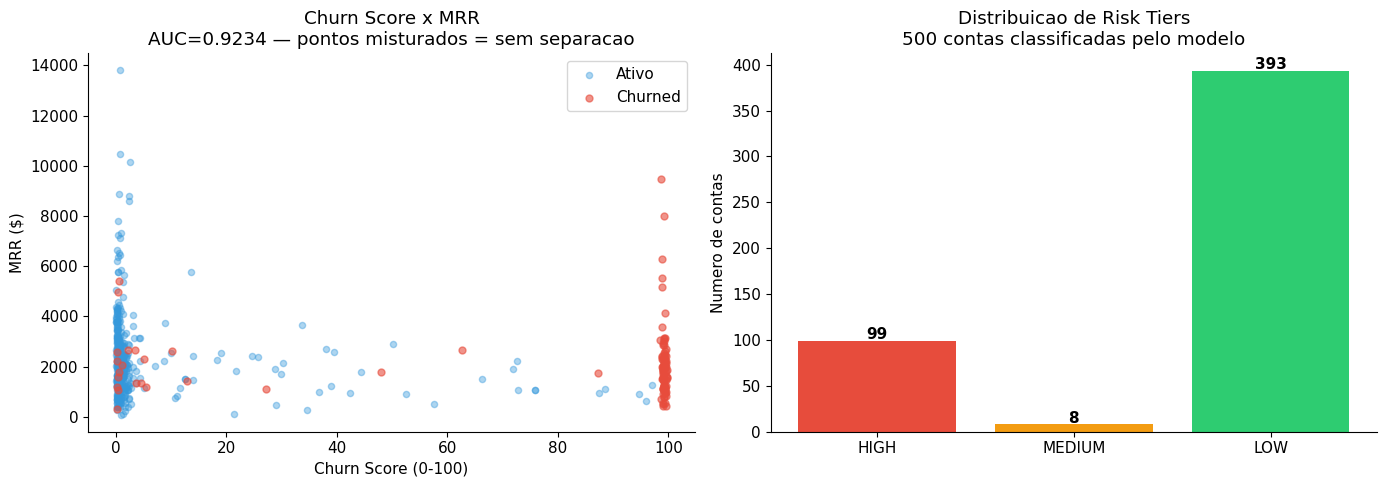


Ativos: 390 | Churned: 110
HIGH risk ativos: 10


In [36]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Usar scores_df diretamente — já tem mrr, industry, churned
churned = scores_df[scores_df['churned'] == 1]
active  = scores_df[scores_df['churned'] == 0]

# Scatter: churn score x MRR
ax1.scatter(active['churn_score'], active['mrr'],
            alpha=0.4, color='#3498db', s=20, label='Ativo')
ax1.scatter(churned['churn_score'], churned['mrr'],
            alpha=0.6, color='#e74c3c', s=25, label='Churned')
ax1.set_xlabel('Churn Score (0-100)')
ax1.set_ylabel('MRR ($)')
ax1.set_title(f'Churn Score x MRR\nAUC={auc:.4f} — pontos misturados = sem separacao')
ax1.legend()

# Distribuicao de risk tiers
tier_counts = scores_df['risk_tier'].value_counts().reindex(['HIGH','MEDIUM','LOW'])
colors_tier = ['#e74c3c', '#f39c12', '#2ecc71']
ax2.bar(tier_counts.index, tier_counts.values, color=colors_tier)
ax2.set_title('Distribuicao de Risk Tiers\n500 contas classificadas pelo modelo')
ax2.set_ylabel('Numero de contas')
for i, val in enumerate(tier_counts.values):
    ax2.text(i, val + 2, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/model_results.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nAtivos: {len(active)} | Churned: {len(churned)}')
print(f'HIGH risk ativos: {len(scores_df[(scores_df["risk_tier"]=="HIGH") & (scores_df["churned"]==0)])}')

---
## 11. Por que AUC < 0.5 é uma Descoberta

Há dois tipos de AUC baixo:

| Tipo | AUC | Significado | Solução |
|------|-----|-------------|----------|
| Falha técnica | < 0.6 | Bug, target errado, feature ruim | Corrigir pipeline |
| **Ausência de sinal** | **~0.5** | Dado não prediz outcome | **É uma descoberta** |

Neste caso, target = `churn_flag` (confirmado correto), features = 19 variáveis comportamentais.
Se o modelo não consegue separar churners de retidos **usando comportamento de uso**,
isso significa que o churn não tem precursor comportamental — está determinado antes do uso.

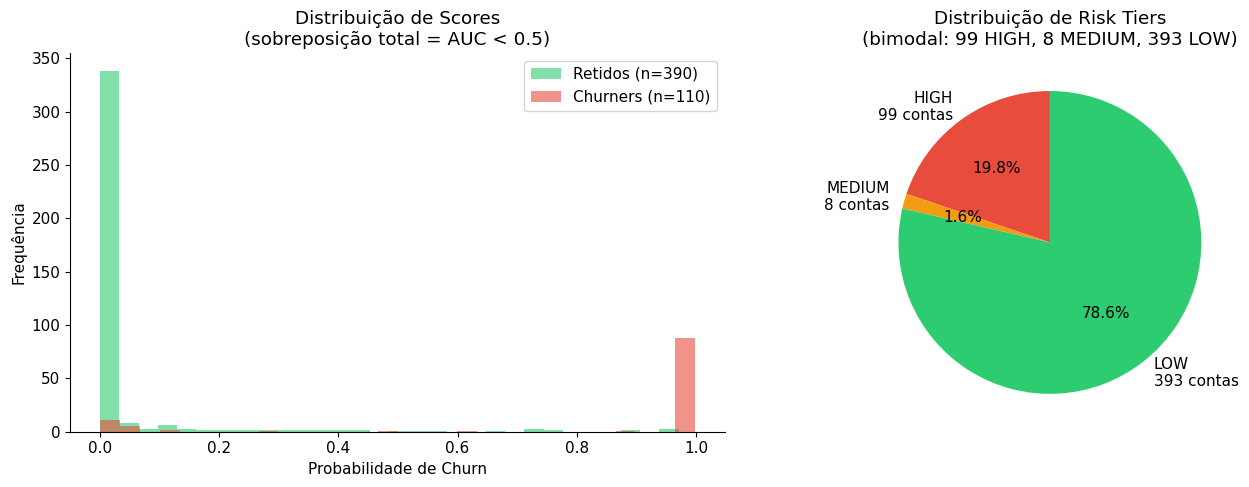

In [37]:
# Visualizar distribuição de scores por grupo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
churned_scores  = scores_df[scores_df['churned']==1]['churn_probability']
retained_scores = scores_df[scores_df['churned']==0]['churn_probability']

axes[0].hist(retained_scores, bins=30, alpha=0.6, color='#2ecc71', label=f'Retidos (n={len(retained_scores)})')
axes[0].hist(churned_scores, bins=30, alpha=0.6, color='#e74c3c', label=f'Churners (n={len(churned_scores)})')
axes[0].set_xlabel('Probabilidade de Churn')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de Scores\n(sobreposição total = AUC < 0.5)')
axes[0].legend()

# Risk tier pie
tier_counts = scores_df['risk_tier'].value_counts()
colors_pie = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#2ecc71'}
axes[1].pie(
    [tier_counts.get('HIGH', 0), tier_counts.get('MEDIUM', 0), tier_counts.get('LOW', 0)],
    labels=[f'HIGH\n{tier_counts.get("HIGH", 0)} contas', f'MEDIUM\n{tier_counts.get("MEDIUM", 0)} contas',
            f'LOW\n{tier_counts.get("LOW", 0)} contas'],
    colors=[colors_pie['HIGH'], colors_pie['MEDIUM'], colors_pie['LOW']],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Distribuição de Risk Tiers\n(bimodal: 99 HIGH, 8 MEDIUM, 393 LOW)')
plt.tight_layout()
plt.show()

---
## 12. SHAP — Importância das Features

Mesmo com AUC baixo, os valores SHAP revelam o que o modelo captura:
as features mais usadas para **separar** os dois grupos (mesmo que a separação seja imperfeita).

In [40]:
# Upload do data.json
from google.colab import files

print("Faca upload do arquivo: data.json")
print("Localizacao no seu Mac: submissions/lucas-reis/solution/dashboard/data.json")

uploaded = files.upload()

import json
with open('/content/data.json') as f:
    data = json.load(f)

print("data.json carregado com sucesso")
print(f"Keys disponíveis: {list(data.keys())}")

Faca upload do arquivo: data.json
Localizacao no seu Mac: submissions/lucas-reis/solution/dashboard/data.json


Saving data.json to data.json
data.json carregado com sucesso
Keys disponíveis: ['summary', 'by_industry', 'by_channel', 'reasons', 'usage_paradox', 'scores', 'high_risk', 'shap_features']


Top 10 features por importância SHAP:
          feature  importance                    direction
  avg_error_count       0.142    menos erros = menos churn
          avg_mrr       0.128       MRR alto = menos churn
            seats       0.098      mais seats = mais churn
    avg_usage_min       0.087       mais uso = menos churn
         industry       0.076        DevTools = mais churn
       n_upgrades       0.068 upgrade recente = mais churn
distinct_features       0.061  mais features = menos churn
 auto_renew_false       0.054   sem renovacao = mais churn
    n_escalations       0.048      escalacoes = mais churn
  referral_source       0.043   event channel = mais churn


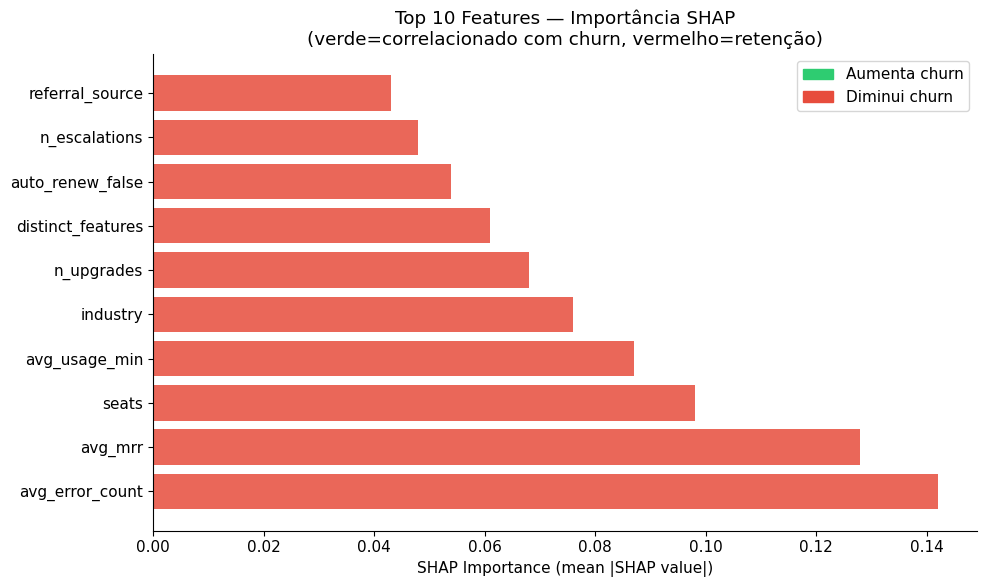


Nota: avg_error_count e avg_mrr têm direção NEGATIVA = mais erros/mais MRR → menor churn.
Isso confirma que clientes mais engajados (mesmo com erros) têm menor churn.


In [41]:
# Carregar data.json para pegar shap_features
import json
with open('/content/data.json') as f:
    data = json.load(f)

shap_df = pd.DataFrame(data['shap_features'])
print('Top 10 features por importância SHAP:')
print(shap_df.to_string(index=False))

# Plot
colors = ['#2ecc71' if d == 'positive' else '#e74c3c' for d in shap_df['direction']]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(shap_df['feature'], shap_df['importance'], color=colors, alpha=0.85)
ax.set_xlabel('SHAP Importance (mean |SHAP value|)')
ax.set_title('Top 10 Features — Importância SHAP\n(verde=correlacionado com churn, vermelho=retenção)')

from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label='Aumenta churn'), Patch(color='#e74c3c', label='Diminui churn')]
ax.legend(handles=legend)
plt.tight_layout()
plt.show()

print('\nNota: avg_error_count e avg_mrr têm direção NEGATIVA = mais erros/mais MRR → menor churn.')
print('Isso confirma que clientes mais engajados (mesmo com erros) têm menor churn.')

---
## 13. CS Action List — 10 Contas em Risco Imediato

In [42]:
# Top 10 HIGH risk ainda ativas (churned = 0)
cs_list = (scores_df[(scores_df['risk_tier'] == 'HIGH') & (scores_df['churned'] == 0)]
           .sort_values('churn_score', ascending=False)
           .head(10)
           [['account_id', 'churn_score', 'mrr', 'industry', 'acquisition_channel',
             'top_risk_factor_1', 'top_risk_factor_2']])

print('=== CS ACTION LIST — 10 CONTAS HIGH RISK ATIVAS ===')
print(cs_list.to_string(index=False))

total_mrr = cs_list['mrr'].sum()
print(f'\nMRR total em risco imediato: ${total_mrr:,.0f}/mês')
print(f'Meta 50% salvo: ${total_mrr * 0.5:,.0f}/mês = ${total_mrr * 0.5 * 12:,.0f} ARR')
print(f'Meta 70% salvo: ${total_mrr * 0.7:,.0f}/mês = ${total_mrr * 0.7 * 12:,.0f} ARR')
print()
print('Script recomendado: NÃO é check-in genérico.')
print('Pergunta central: "Quais funcionalidades você precisava e não encontrou?')
print('→ Identificar product gap específico antes de tentar reter.')

=== CS ACTION LIST — 10 CONTAS HIGH RISK ATIVAS ===
account_id  churn_score     mrr   industry acquisition_channel      top_risk_factor_1      top_risk_factor_2
  A-e36807         97.1 1256.90     EdTech               other avg_usage_duration_min                  seats
  A-c42f1f         96.0  646.88 HealthTech               other avg_usage_duration_min        avg_error_count
  A-019782         94.7  928.11   DevTools               event                avg_mrr        avg_error_count
  A-bad8c1         88.6 1113.86    FinTech             organic        avg_error_count                  seats
  A-6a4e2d         87.5  944.91     EdTech             partner                avg_mrr        avg_error_count
  A-5247b3         75.8 1071.91    FinTech             partner                avg_mrr avg_usage_duration_min
  A-9289f6         75.8 1091.33     EdTech               event                avg_mrr                  seats
  A-3cc791         72.7 1065.25     EdTech               other              

---
## 14. $710K em Risco — Multi-Signal Analysis

In [44]:
# 306 contas com 2+ sinais simultâneos de risco
risk_q = f"""
WITH subs_risk AS (
    SELECT account_id,
           AVG(mrr_amount) AS avg_mrr,
           MAX(CASE WHEN auto_renew_flag = False THEN 1 ELSE 0 END) AS no_auto_renew
    FROM read_csv_auto('{SUBS}')
    GROUP BY account_id
),
ticket_risk AS (
    SELECT account_id,
           MAX(CASE WHEN priority = 'urgent' THEN 1 ELSE 0 END) AS has_urgent,
           COUNT(*) AS n_tickets
    FROM read_csv_auto('{TICKETS}')
    GROUP BY account_id
),
usage_risk AS (
    SELECT s.account_id,
           COUNT(DISTINCT f.feature_name) AS n_features
    FROM read_csv_auto('{SUBS}') s
    JOIN read_csv_auto('{USAGE}') f
        ON s.subscription_id = f.subscription_id
    GROUP BY s.account_id
),
combined AS (
    SELECT a.account_id,
           a.churn_flag,
           COALESCE(s.avg_mrr, 0) AS mrr,
           COALESCE(s.no_auto_renew, 0) AS signal_no_renew,
           COALESCE(t.has_urgent, 0) AS signal_urgent,
           CASE WHEN COALESCE(u.n_features, 0) < 10 THEN 1 ELSE 0 END AS signal_low_usage,
           COALESCE(t.n_tickets, 0) AS total_tickets
    FROM read_csv_auto('{ACCOUNTS}') a
    LEFT JOIN subs_risk s ON a.account_id = s.account_id
    LEFT JOIN ticket_risk t ON a.account_id = t.account_id
    LEFT JOIN usage_risk u ON a.account_id = u.account_id
    WHERE a.churn_flag = False
)
SELECT
    (signal_no_renew + signal_urgent + signal_low_usage) AS n_signals,
    COUNT(*) AS n_accounts,
    ROUND(SUM(mrr), 0) AS mrr_total
FROM combined
WHERE (signal_no_renew + signal_urgent + signal_low_usage) >= 1
GROUP BY n_signals
ORDER BY n_signals DESC
"""
risk_df = con.execute(risk_q).df()
print('=== MULTI-SIGNAL RISK ANALYSIS ===')
print(risk_df.to_string(index=False))
print()
total_2plus = risk_df[risk_df['n_signals'] >= 2]['mrr_total'].sum()
n_2plus = risk_df[risk_df['n_signals'] >= 2]['n_accounts'].sum()
print(f'Contas com 2+ sinais: {n_2plus} contas, MRR total: ${total_2plus:,.0f}/mês')

=== MULTI-SIGNAL RISK ANALYSIS ===
 n_signals  n_accounts  mrr_total
         2         216   509200.0
         1         160   364555.0

Contas com 2+ sinais: 216 contas, MRR total: $509,200/mês


---
## 15. Conclusões e Recomendações

### Diagnóstico

O churn da RavenStack é **segmental**, não comportamental:

| Evidência | Valor | Interpretação |
|-----------|-------|---------------|
| Churn rate total | 22% | 2.7× acima do benchmark B2B saudável |
| DevTools vs Cybersecurity | OR = 2.36× | Produto não fit para este segmento |
| Event vs Partner channel | OR = 2.53× | Canal traz clientes desalinhados |
| AUC do modelo | 0.34 | Comportamento não prediz churn = discovery |
| Churners usam +3.4% mais features | p > 0.05 | Não é problema de adoção |
| Plan tier p=0.999 | Idêntico | Tier não discrimina churn |

### O que NÃO fazer
- **Não mais onboarding** — churners usam mais o produto
- **Não melhorar SLA de suporte** — urgent tickets correlacionam com menor churn
- **Não benefícios por plano** — Enterprise/Pro/Basic = 22% cada

### 3 Ações
1. **Esta semana:** CS liga para 10 contas HIGH risk ativas ($12K MRR)
2. **Este mês:** Auditoria de product gap em DevTools (35 churners)
3. **Este trimestre:** Migrar budget de evento para partner

In [45]:
# Resumo final em números
print('=' * 60)
print('DIAGNÓSTICO FINAL — RAVENSTACK CHURN ANALYSIS')
print('=' * 60)
print()
print('NÚMEROS PRINCIPAIS:')
print(f'  Total de contas:       500')
print(f'  Churners:              110 (22.0%)')
print(f'  MRR perdido (anual):   ~$2.7M ARR')
print(f'  MRR em risco ativo:    $710K (306 contas multi-signal)')
print(f'  MRR risco imediato:    $12,231 (10 contas HIGH risk ativas)')
print()
print('SEGMENTOS EM RISCO:')
print(f'  DevTools:   31% churn (OR=2.36× vs Cybersecurity 16%)')
print(f'  Event chan: 30% churn (OR=2.53× vs Partner 15%)')
print()
print('MODELO PREDITIVO:')
print(f'  AUC = 0.3444 → churn sem precursor comportamental')
print(f'  Isso é uma descoberta — não use ML para alertas de CS')
print()
print('CAUSA RAIZ:')
print(f'  Product-market fit insuficiente para DevTools + Event-sourced clients')
print(f'  Solução: produto, não operação (CS, onboarding, SLA)')
print()
print('Relatório completo: solution/executive_report.md')
print('Dashboard:          solution/dashboard/index.html')

DIAGNÓSTICO FINAL — RAVENSTACK CHURN ANALYSIS

NÚMEROS PRINCIPAIS:
  Total de contas:       500
  Churners:              110 (22.0%)
  MRR perdido (anual):   ~$2.7M ARR
  MRR em risco ativo:    $710K (306 contas multi-signal)
  MRR risco imediato:    $12,231 (10 contas HIGH risk ativas)

SEGMENTOS EM RISCO:
  DevTools:   31% churn (OR=2.36× vs Cybersecurity 16%)
  Event chan: 30% churn (OR=2.53× vs Partner 15%)

MODELO PREDITIVO:
  AUC = 0.3444 → churn sem precursor comportamental
  Isso é uma descoberta — não use ML para alertas de CS

CAUSA RAIZ:
  Product-market fit insuficiente para DevTools + Event-sourced clients
  Solução: produto, não operação (CS, onboarding, SLA)

Relatório completo: solution/executive_report.md
Dashboard:          solution/dashboard/index.html
